In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

2026-07-28 10:08:35.645034: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-28 10:08:35.727025: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-28 10:08:35.831410: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785233315.938939    1177 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785233315.970775    1177 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1785233316.127246    1177 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [2]:
train_dir = Path("dataset/train")
val_dir = Path("dataset/val")
test_dir = Path("dataset/test")

In [3]:
BATCH_SIZE = 32  #32 images at a time if 3200 images then 100 steps per epoch
IMG_SIZE = (224, 224) ##every image must be same size resize to 224x224

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 1400 files belonging to 10 classes.
Found 200 files belonging to 10 classes.


2026-07-28 10:08:43.657124: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
class_names = train_ds.class_names
class_names

['SUV',
 'bus',
 'family sedan',
 'fire engine',
 'heavy truck',
 'jeep',
 'minibus',
 'racing car',
 'taxi',
 'truck']

In [6]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


2026-07-28 10:08:45.938514: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(len(class_names), activation="softmax")
])

/usr/local/lib/python3.11/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,722 (49.36 MB)

 Trainable params: 12,939,722 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
#the model overfitted after 10 epochs, so we will use early stopping to prevent overfitting
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20


/usr/local/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


44/44 ━━━━━━━━━━━━━━━━━━━━ 190s 4s/step - accuracy: 0.1450 - loss: 2.4312 - val_accuracy: 0.2450 - val_loss: 2.0953
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 190s 4s/step - accuracy: 0.3171 - loss: 1.9302 - val_accuracy: 0.4650 - val_loss: 1.6732
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 174s 4s/step - accuracy: 0.4793 - loss: 1.5075 - val_accuracy: 0.5400 - val_loss: 1.3936
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 211s 5s/step - accuracy: 0.6107 - loss: 1.1677 - val_accuracy: 0.5550 - val_loss: 1.2736
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 199s 4s/step - accuracy: 0.6821 - loss: 0.9499 - val_accuracy: 0.5800 - val_loss: 1.2168
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 182s 4s/step - accuracy: 0.7743 - loss: 0.6619 - val_accuracy: 0.6050 - val_loss: 1.1660
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 213s 5s/step - accuracy: 0.8500 - loss: 0.4835 - val_accuracy: 0.6250 - val_loss: 1.2855
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 226s 5s/step - accuracy: 0.8786 - loss: 0.3592 - val_accuracy: 0.6450 - val_loss: 1.

In [12]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

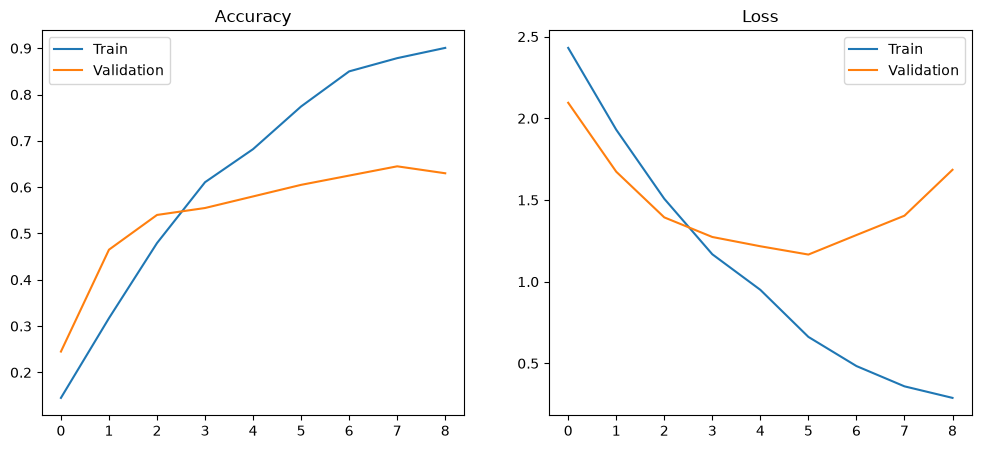

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.show()

In [14]:
loss, accuracy = model.evaluate(val_ds)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy*100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 615ms/step - accuracy: 0.6050 - loss: 1.1660
Validation Loss: 1.1660
Validation Accuracy: 60.50%


In [15]:
history.history

{'accuracy': [0.14499999582767487,
  0.3171428442001343,
  0.47928571701049805,
  0.6107142567634583,
  0.6821428537368774,
  0.7742857336997986,
  0.8500000238418579,
  0.8785714507102966,
  0.9007142782211304],
 'loss': [2.4311976432800293,
  1.9302160739898682,
  1.5074914693832397,
  1.167715072631836,
  0.9499383568763733,
  0.6618924736976624,
  0.4834636151790619,
  0.35921719670295715,
  0.2885311245918274],
 'val_accuracy': [0.24500000476837158,
  0.4650000035762787,
  0.5400000214576721,
  0.5550000071525574,
  0.5799999833106995,
  0.6050000190734863,
  0.625,
  0.6449999809265137,
  0.6299999952316284],
 'val_loss': [2.0952961444854736,
  1.6732128858566284,
  1.393568754196167,
  1.2735569477081299,
  1.2167526483535767,
  1.1659955978393555,
  1.2854596376419067,
  1.403894066810608,
  1.684971570968628]}

2026-07-28 10:39:01.300750: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


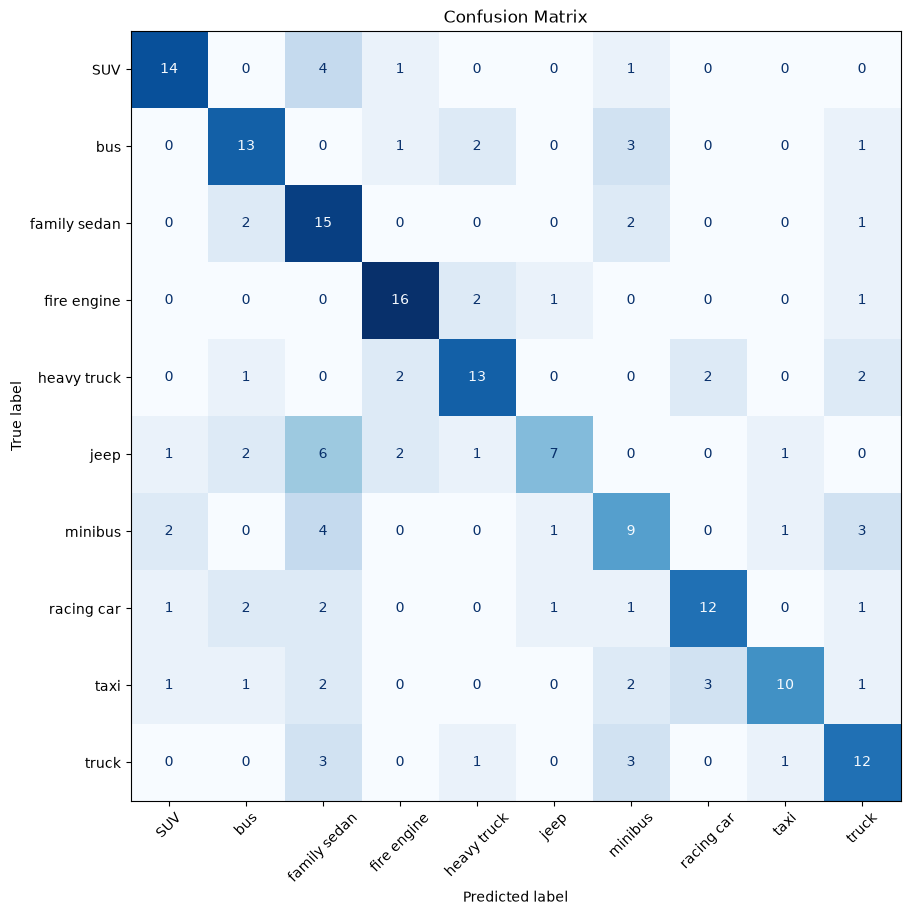


Classification Report:

              precision    recall  f1-score   support

         SUV       0.74      0.70      0.72        20
         bus       0.62      0.65      0.63        20
family sedan       0.42      0.75      0.54        20
 fire engine       0.73      0.80      0.76        20
 heavy truck       0.68      0.65      0.67        20
        jeep       0.70      0.35      0.47        20
     minibus       0.43      0.45      0.44        20
  racing car       0.71      0.60      0.65        20
        taxi       0.77      0.50      0.61        20
       truck       0.55      0.60      0.57        20

    accuracy                           0.60       200
   macro avg       0.63      0.60      0.60       200
weighted avg       0.63      0.60      0.60       200



In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

In [17]:
model.save("vehicle_classifier.keras")

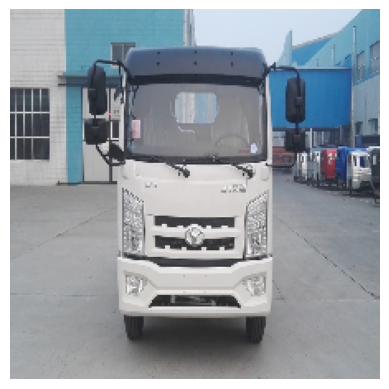

Prediction : minibus
Confidence : 44.23%


In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Path to your image
image_path = r"dataset/test/0a5067c35b854ce7213e433d12ea500d.jpg"

# Load image
img = tf.keras.utils.load_img(
    image_path,
    target_size=(224, 224)
)

# Display image
plt.imshow(img)
plt.axis("off")
plt.show()

# Preprocess
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array, verbose=0)

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

print(f"Prediction : {predicted_class}")
print(f"Confidence : {confidence:.2f}%")